In [8]:
import numpy as np

def croston_classic(ts, alpha=0.1, n_forecast=7):
    ts = np.array(ts)
    n = len(ts)
    demand = np.where(ts != 0, ts, np.nan)
    interval = np.full_like(ts, np.nan, dtype='float')
    
    # Talep gelen noktalar arası aralık
    last_demand_index = np.nan
    for i in range(n):
        if ts[i] != 0:
            if np.isnan(last_demand_index):
                interval[i] = np.nan
            else:
                interval[i] = i - last_demand_index
            last_demand_index = i

    a_demand = np.nanmean(demand)
    a_interval = np.nanmean(interval)

    forecasts = []
    for _ in range(n_forecast):
        forecasts.append(a_demand / a_interval if a_interval > 0 else 0)

    return forecasts

def find_best_sarimax_order(ts, train_end_date, full_series):
    best_mape = np.inf
    best_order = None
    best_seasonal_order = None

    ts = ts.dropna()

    # ADF testi
    try:
        adf_pvalue = adfuller(ts)[1]
        d = 0 if adf_pvalue < 0.05 else 1
    except:
        d = 0

    # ACF testi
    try:
        acf_values = acf(ts, nlags=24)
        if len(acf_values) > 12 and acf_values[12] > 0.3:
            seasonal = True
            s = 12
        else:
            seasonal = False
            s = 0
    except:
        seasonal = False
        s = 0

    for p in range(0, 3):
        for q in range(0, 3):
            try:
                if seasonal:
                    seasonal_order = (1,0,1,s)
                else:
                    seasonal_order = (0,0,0,0)

                model = SARIMAX(ts, order=(p,d,q), seasonal_order=seasonal_order,
                                enforce_stationarity=False, enforce_invertibility=False)
                results = model.fit(disp=False)

                forecast = results.get_forecast(steps=7)
                forecast_mean = forecast.predicted_mean

                test_data = full_series.loc[train_end_date:]
                common_months = test_data.index.intersection(forecast_mean.index)

                if len(common_months) == 0:
                    continue

                actual = test_data.loc[common_months]
                predicted = forecast_mean.loc[common_months]

                mape = mean_absolute_percentage_error(actual, predicted) * 100

                if mape < best_mape:
                    best_mape = mape
                    best_order = (p,d,q)
                    best_seasonal_order = seasonal_order

            except:
                continue

    if best_order is None:
        best_order = (1,0,1)
        best_seasonal_order = (0,0,0,0)
        best_mape = np.nan

    return best_order, best_seasonal_order, best_mape


/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Grade 'A' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -429.293
Date:                Thu, 22 May 2025   AIC                            864.585
Time:                        22:20:38   BIC                            869.498
Sample:                    01-01-2022   HQIC                           866.333
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9970      0.005    193.746      0.000       0.987       1.007
ma.L1         -0.7516      0

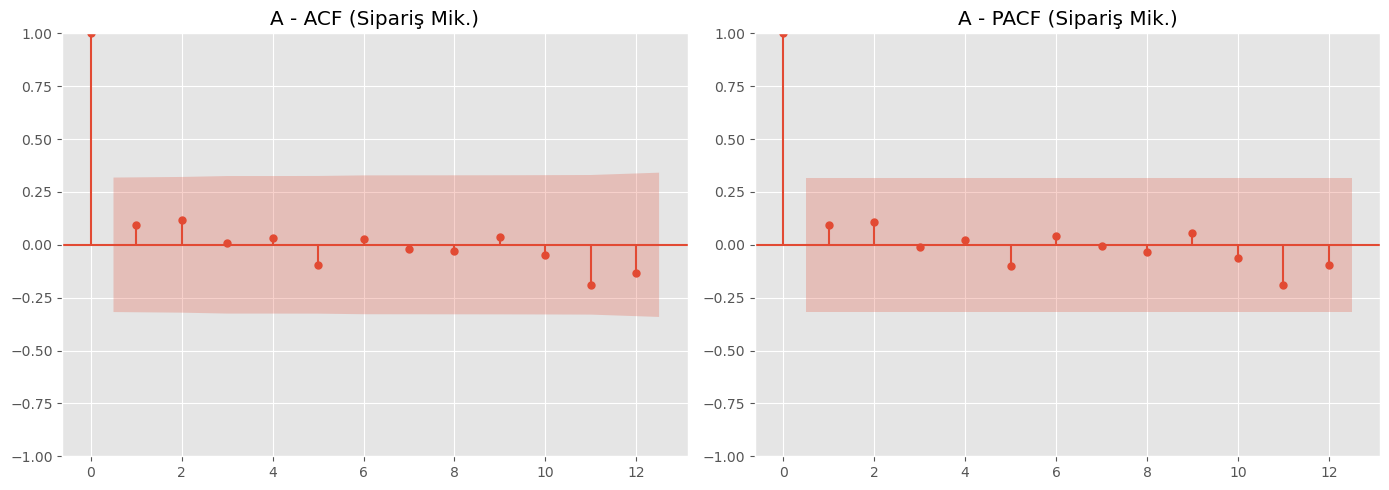

/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Grade 'B' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -255.252
Date:                Thu, 22 May 2025   AIC                            516.504
Time:                        22:20:39   BIC                            521.417
Sample:                    01-01-2022   HQIC                           518.252
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9794      0.041     23.651      0.000       0.898       1.061
ma.L1         -0.7775      0

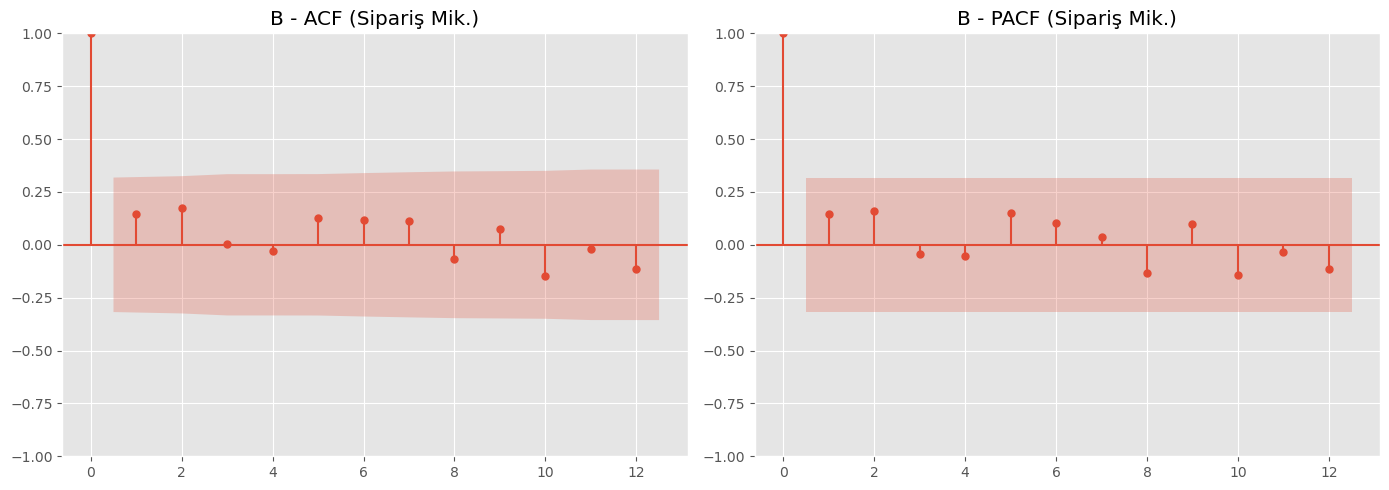

Grade 'C' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -296.442
Date:                Thu, 22 May 2025   AIC                            598.883
Time:                        22:20:40   BIC                            603.796
Sample:                    01-01-2022   HQIC                           600.631
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8246      0.183      4.516      0.000       0.467       1.182
ma.L1         -0.4339      0

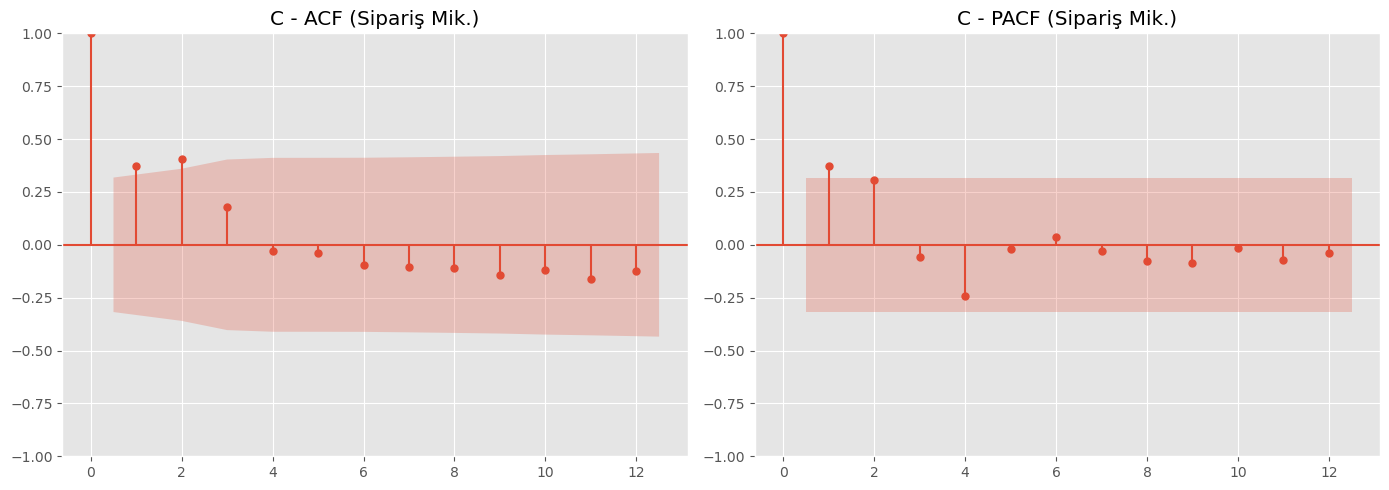

Grade 'D' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -338.863
Date:                Thu, 22 May 2025   AIC                            683.725
Time:                        22:20:40   BIC                            688.638
Sample:                    01-01-2022   HQIC                           685.473
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.001    745.570      0.000       0.997       1.003
ma.L1         -0.9946      0

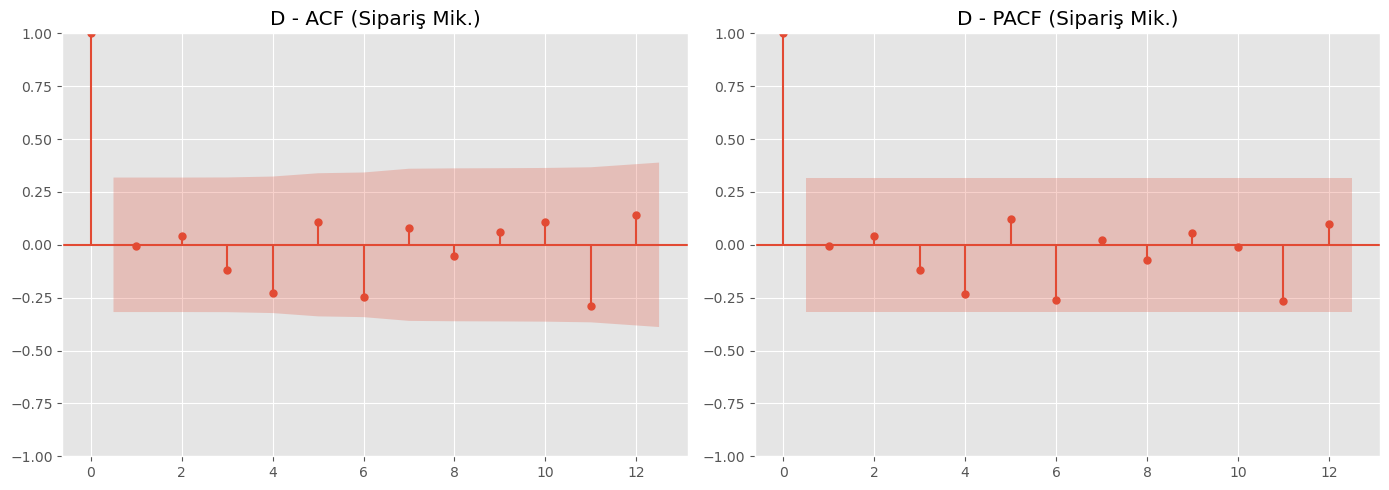

Grade 'DD11' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -364.895
Date:                Thu, 22 May 2025   AIC                            735.789
Time:                        22:20:41   BIC                            740.702
Sample:                    01-01-2022   HQIC                           737.537
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9798      0.024     40.829      0.000       0.933       1.027
ma.L1         -0.8368    

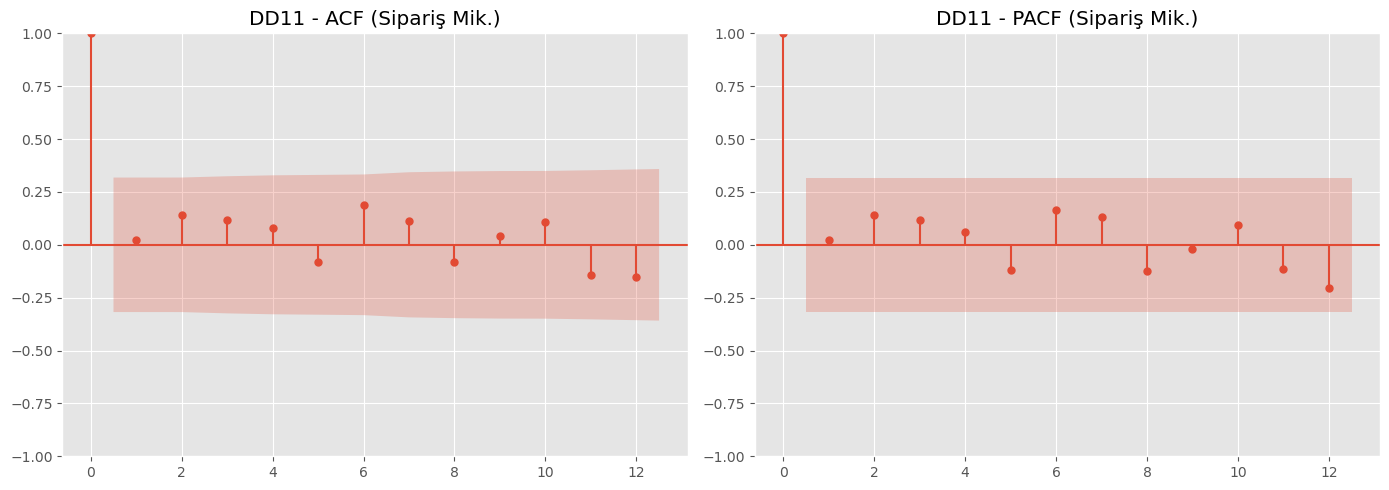

Grade 'DD11-1' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -389.168
Date:                Thu, 22 May 2025   AIC                            784.335
Time:                        22:20:41   BIC                            789.248
Sample:                    01-01-2022   HQIC                           786.083
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000   1.21e-07   8.27e+06      0.000       1.000       1.000
ma.L1         -0.2846  

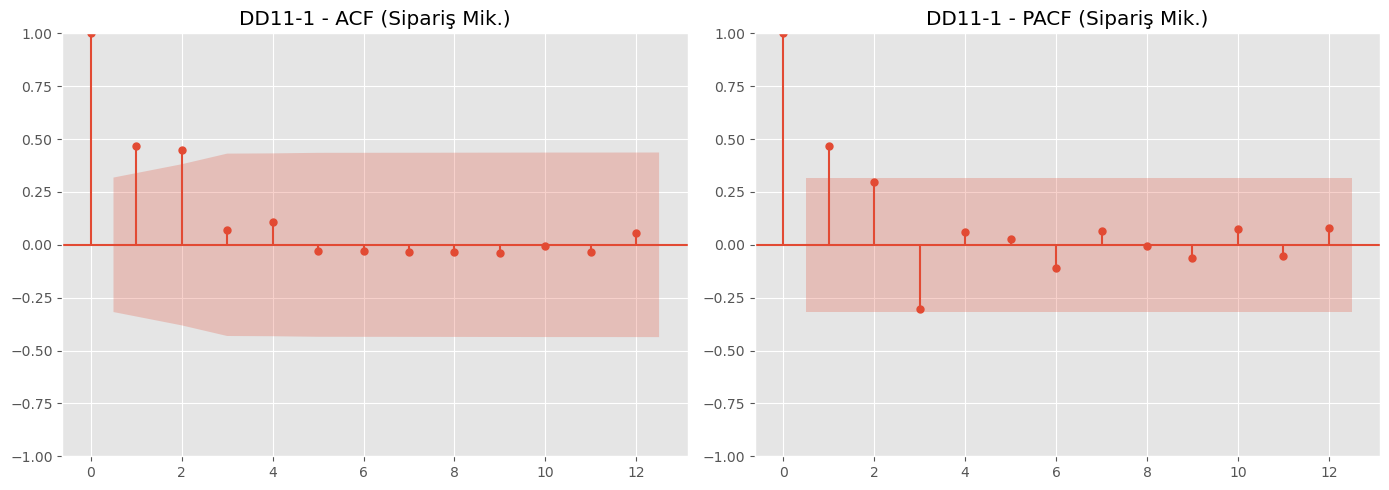

Grade 'DD11-2' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -324.662
Date:                Thu, 22 May 2025   AIC                            655.324
Time:                        22:20:42   BIC                            660.236
Sample:                    01-01-2022   HQIC                           657.072
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0726   3.16e+04   -2.3e-06      1.000   -6.18e+04    6.18e+04
ma.L1          0.0731  

/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


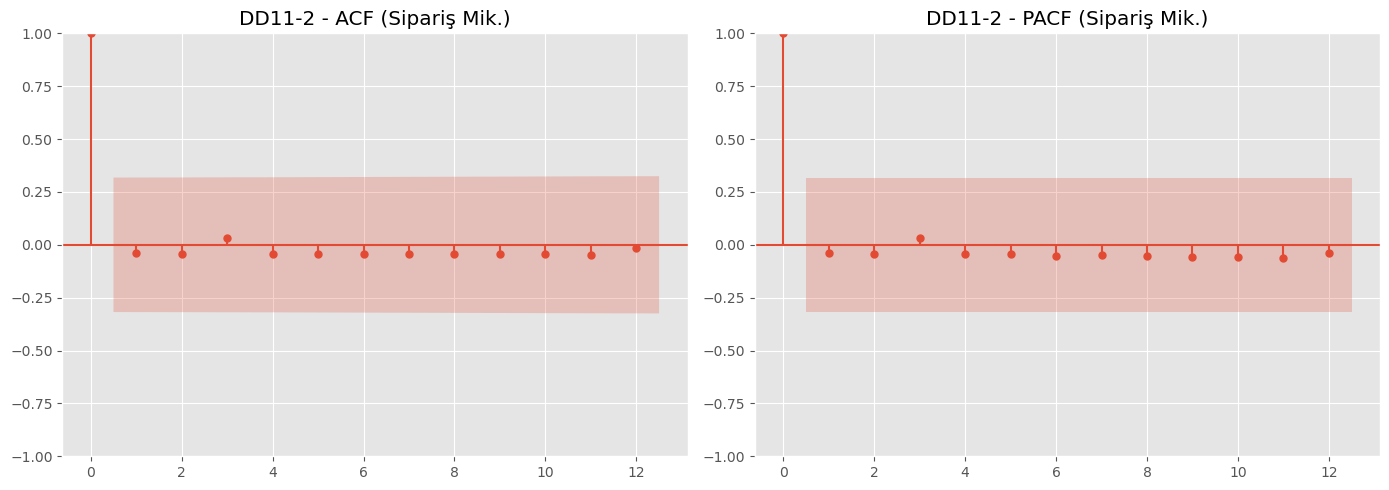

DD11-2 için 2025-04 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
DD11-2 için 2025-05 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
Grade 'DD13' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -233.667
Date:                Thu, 22 May 2025   AIC                            473.334
Time:                        22:20:42   BIC                            478.247
Sample:                    01-01-2022   HQIC                           475.082
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------

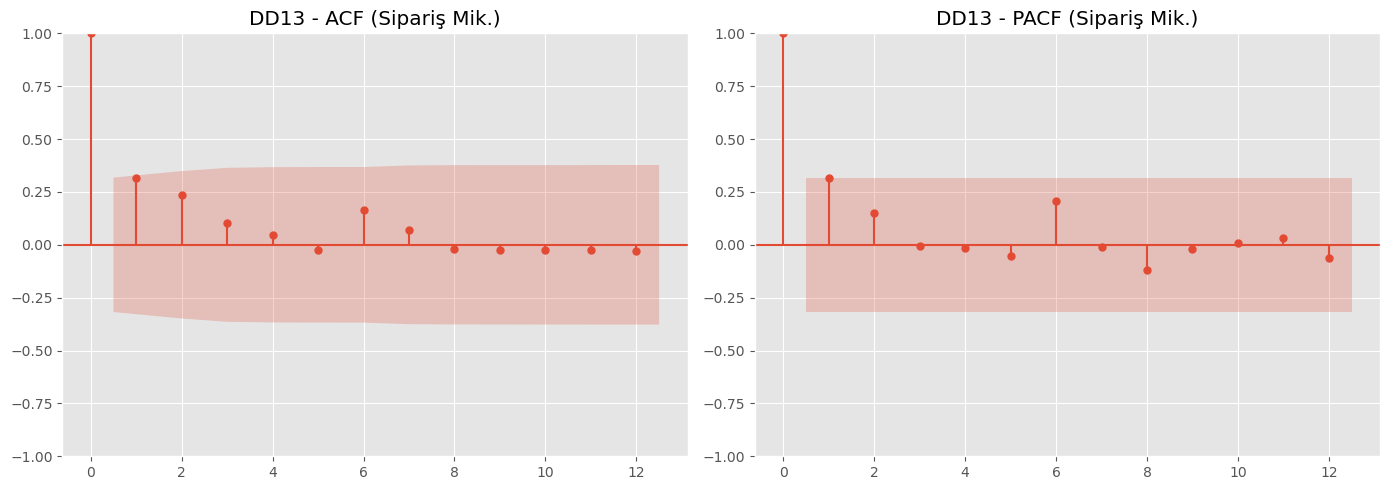

DD13 için 2025-05 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
Grade 'E' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -259.831
Date:                Thu, 22 May 2025   AIC                            525.662
Time:                        22:20:42   BIC                            530.575
Sample:                    01-01-2022   HQIC                           527.410
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9725    

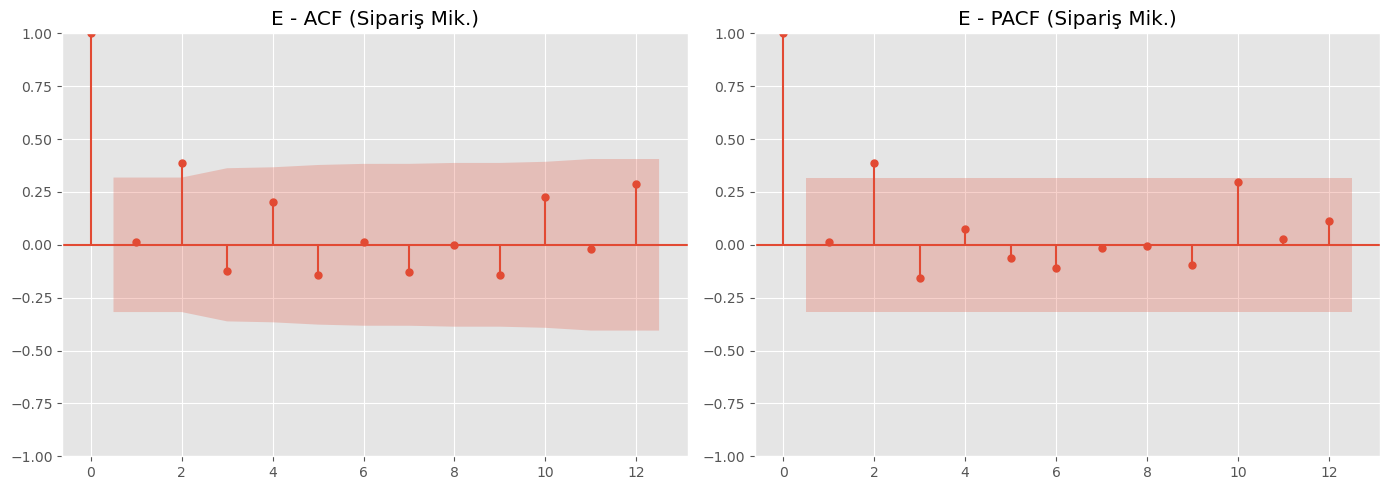

Grade 'P265NB' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -256.502
Date:                Thu, 22 May 2025   AIC                            519.005
Time:                        22:20:43   BIC                            523.918
Sample:                    01-01-2022   HQIC                           520.753
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3167   3.74e+10   8.47e-12      1.000   -7.33e+10    7.33e+10
ma.L1         -0.3167  

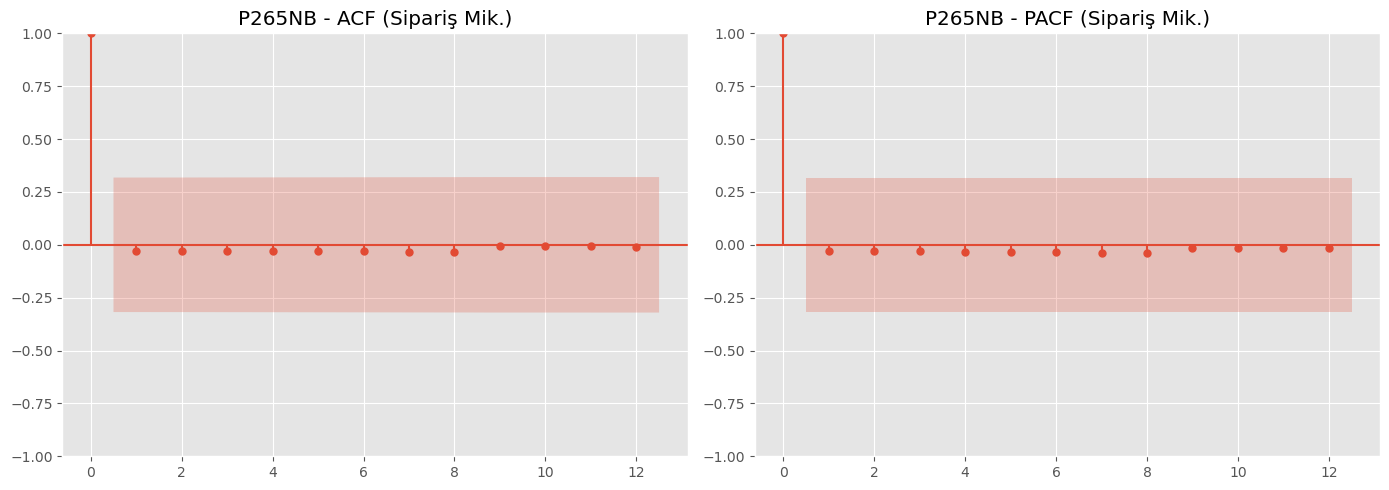

P265NB için 2025-03 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
P265NB için 2025-04 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
P265NB için 2025-05 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
Grade 'S235JR' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -415.263
Date:                Thu, 22 May 2025   AIC                            836.527
Time:                        22:20:43   BIC                            841.440
Sample:                    01-01-2022   HQIC                           838.275
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
        

/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


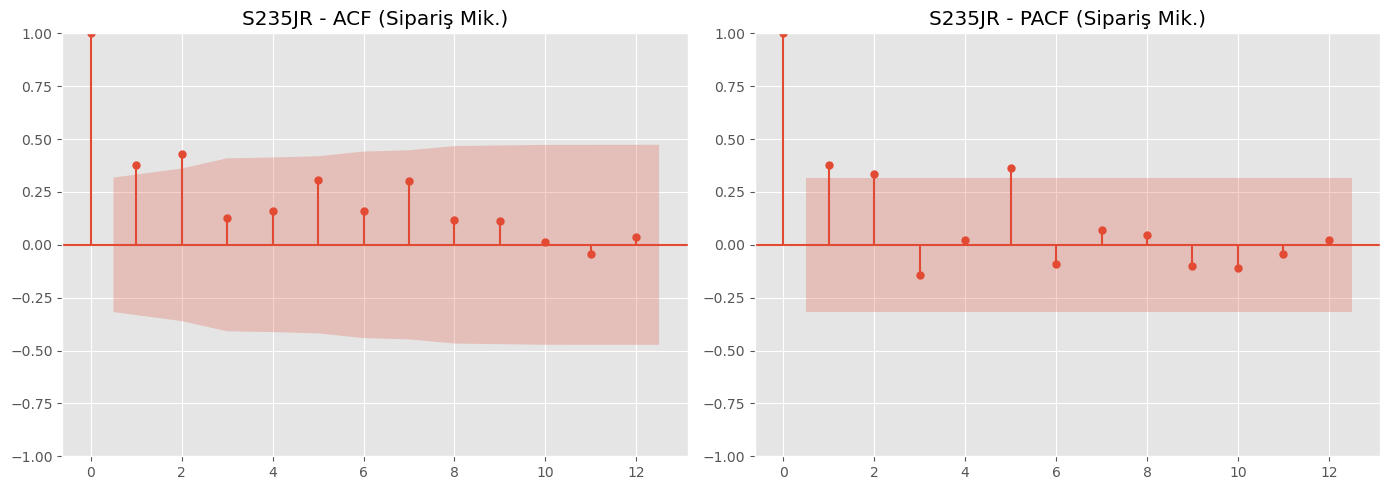

Grade 'S235JR-1' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -329.497
Date:                Thu, 22 May 2025   AIC                            664.993
Time:                        22:20:44   BIC                            669.906
Sample:                    01-01-2022   HQIC                           666.741
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6265      0.264      2.376      0.017       0.110       1.143
ma.L1         -0.0490

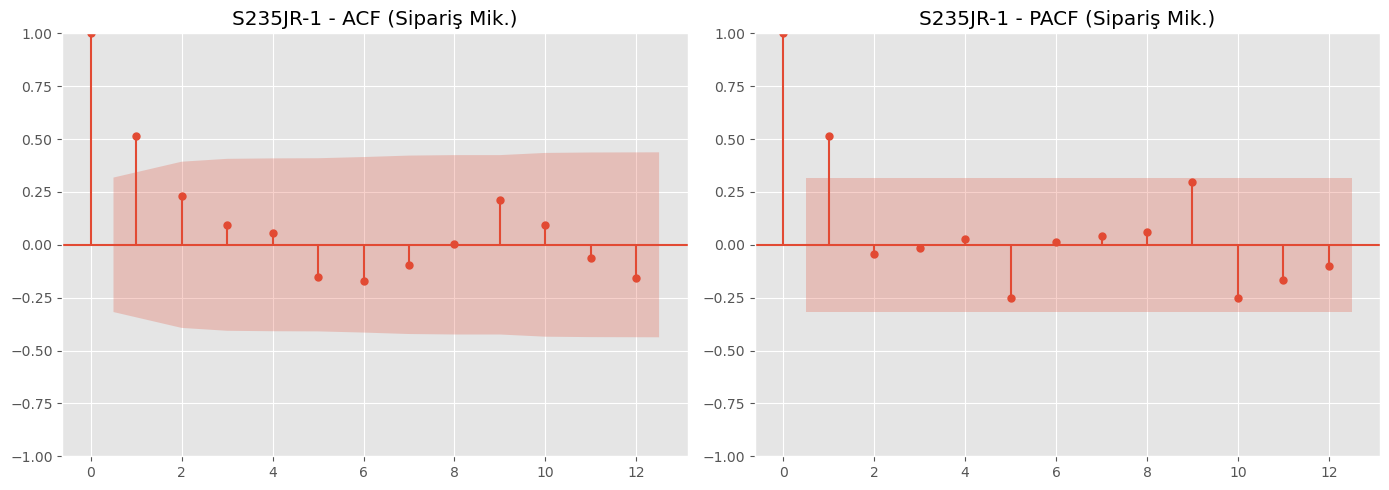

/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packag

Grade 'S235JR-CL3' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -227.898
Date:                Thu, 22 May 2025   AIC                            461.795
Time:                        22:20:44   BIC                            466.708
Sample:                    01-01-2022   HQIC                           463.543
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0412   4.82e+04   8.54e-07      1.000   -9.44e+04    9.44e+04
ma.L1         -0.03

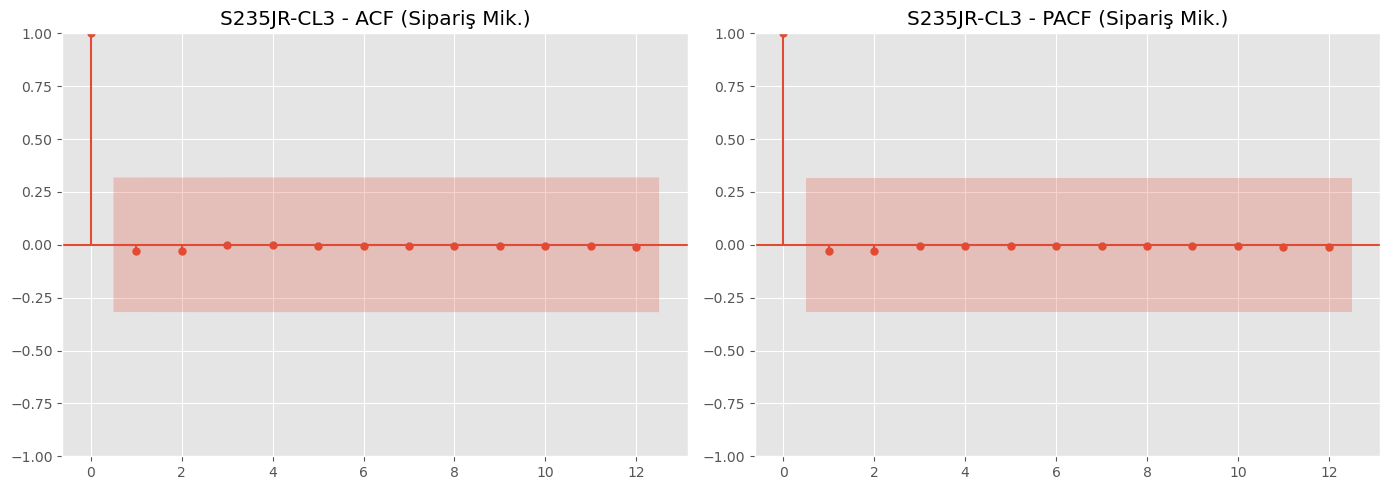

S235JR-CL3 için 2025-04 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S235JR-CL3 için 2025-05 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
Grade 'S275J2' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -221.103
Date:                Thu, 22 May 2025   AIC                            448.206
Time:                        22:20:45   BIC                            453.119
Sample:                    01-01-2022   HQIC                           449.954
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----

/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


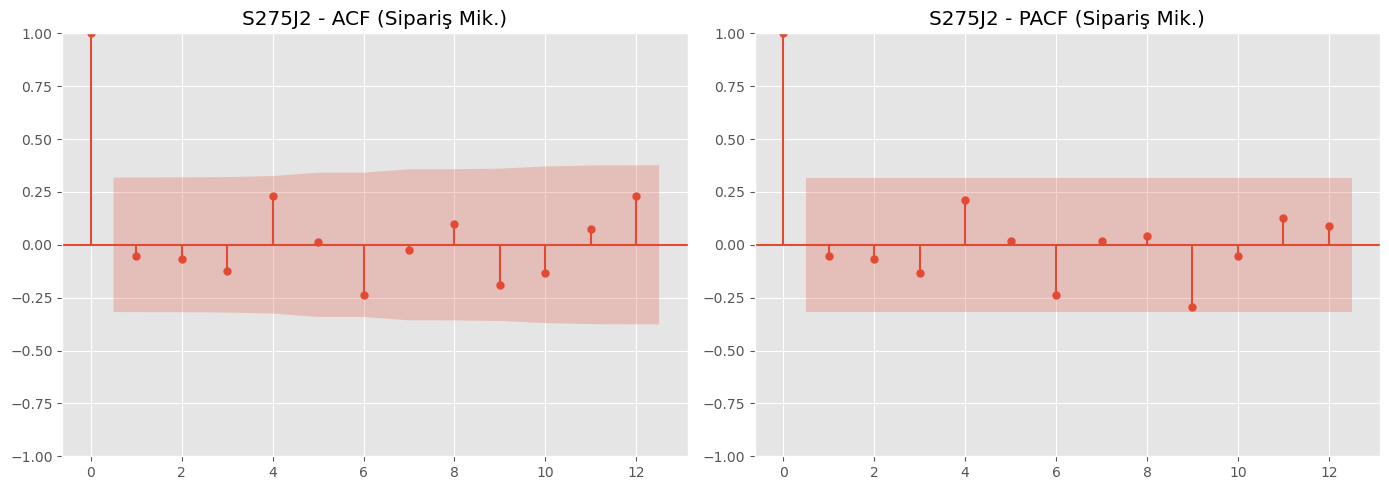

/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Grade 'S275JR' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -258.827
Date:                Thu, 22 May 2025   AIC                            523.655
Time:                        22:20:45   BIC                            528.567
Sample:                    01-01-2022   HQIC                           525.403
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9686      0.029     33.151      0.000       0.911       1.026
ma.L1         -0.7045  

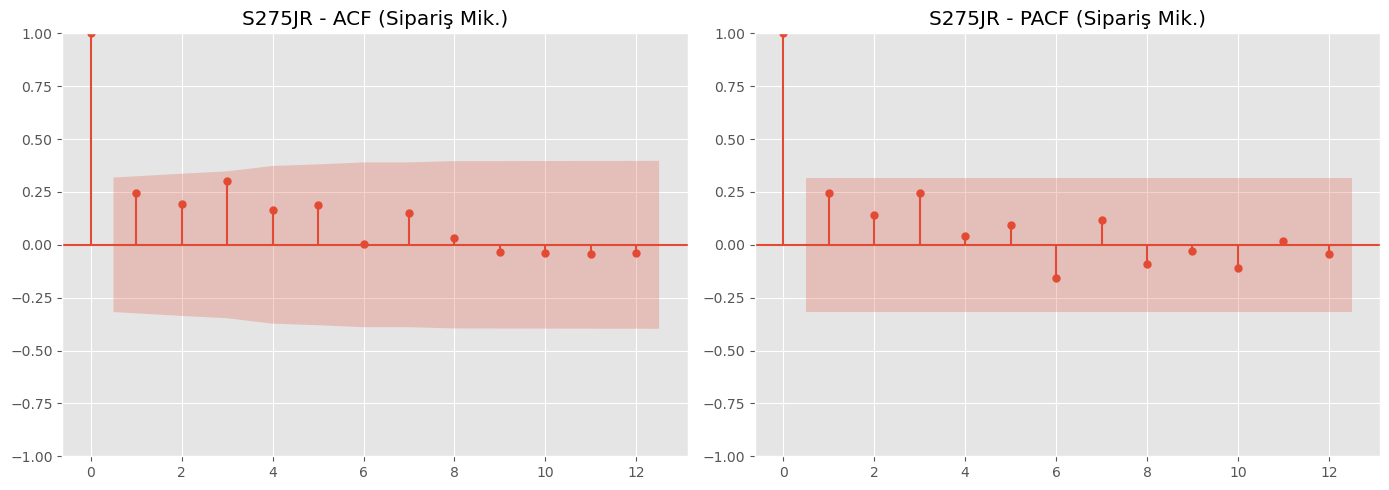

S275JR için 2025-05 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
Grade 'S355J2' için seçilen SARIMAX order (MAPE bazlı): (1, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: nan%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   38
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -228.123
Date:                Thu, 22 May 2025   AIC                            462.247
Time:                        22:20:45   BIC                            467.159
Sample:                    01-01-2022   HQIC                           463.995
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6

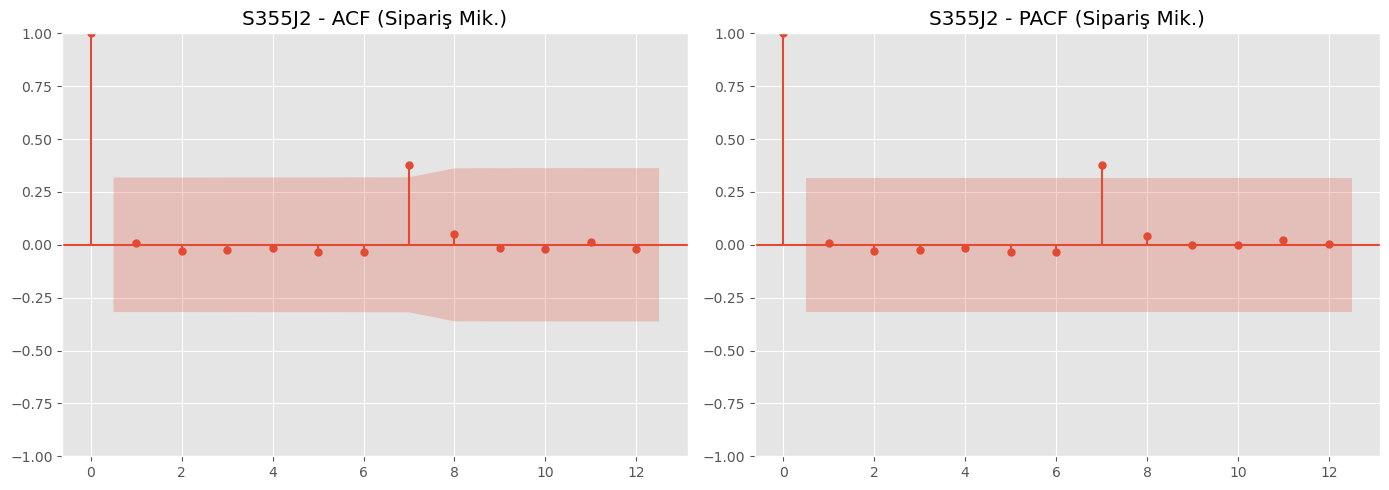

S355J2 için 2025-03 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S355J2 için 2025-04 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S355J2 için 2025-05 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.


In [9]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

np.set_printoptions(suppress=True)
pd.options.display.float_format = '{:,.2f}'.format

# 1. Veri yükleme
df = pd.read_excel('../preprocessedBelgeler/NewforecastData_altLimit100_son3_byGrup.xlsx')  # Dosya adını değiştir
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)', 'GradeGroup']
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# 2. Aylık grade bazlı toplam sipariş
monthly_grade = df.groupby(['Month', 'GradeGroup'])['Sipariş Mik. (TON)'].sum().reset_index()
grade_list = monthly_grade['GradeGroup'].unique()

# Tahminler ve dağıtılmış sonuçlar için boş dataframe
forecast_df = pd.DataFrame()
train_forecast_df = pd.DataFrame()
disaggregated_df = pd.DataFrame()
disaggregated_forecast_df = pd.DataFrame()


mae_list = []
mape_list = []

sarimax_param_log = []

# 3. Her grade için SARIMAX modeli ile tahmin
for grade in grade_list:
    # 1. Grade'e ait zaman serisini hazırla
    grade_data = monthly_grade[monthly_grade['GradeGroup'] == grade].set_index('Month')
    
    # 🔒 Model verisini 2018-01 ile 2024-12 arasında sınırla
    grade_data = grade_data.loc['2022-01':'2025-02']

    grade_ts = grade_data['Sipariş Mik. (TON)'].asfreq('MS').fillna(0)
    
    # 2. ❗ Sabit ya da boş seri kontrolü
    if grade_ts.std() < 1e-3 or grade_ts.sum() == 0:
        print(f"'{grade}' atlandı çünkü zaman serisi sabit veya boş.")
        continue  # bu grade'i atla

   

    # 3. SARIMAX Modeli
    try:
        # 🔥 Grade'e özel en iyi order'ı, seasonal order'ı ve best_mape'i bul
        full_grade_data = monthly_grade[monthly_grade['GradeGroup'] == grade].set_index('Month')  # full series data çekiyoruz
        full_grade_data = full_grade_data.loc['2022-01':'2025-02']  # geçmiş+gelecek tüm veri

        best_order, best_seasonal_order, best_mape = find_best_sarimax_order(
            grade_ts, 
            train_end_date='2025-03-01', 
            full_series=full_grade_data['Sipariş Mik. (TON)'].asfreq('MS').fillna(0)
        )

        print(f"Grade '{grade}' için seçilen SARIMAX order (MAPE bazlı): {best_order}, seasonal_order: {best_seasonal_order}, MAPE: {best_mape:.2f}%")

        # 🔥 SARIMAX Modeli kur
        model = SARIMAX(grade_ts, order=best_order, seasonal_order=best_seasonal_order)
        results = model.fit(disp=False)
        print(results.summary())
        # 🔥 Logla
        sarimax_param_log.append({
            'GradeGroup': grade,
            'Order': best_order,
            'Seasonal_Order': best_seasonal_order,
            'MAPE (%)': round(best_mape, 2)
        })



    except Exception as e:
        print(f"{grade} için model kurulamadı: {e}")
        continue

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    plot_acf(grade_ts, lags=12, ax=ax[0])
    ax[0].set_title(f"{grade} - ACF (Sipariş Mik.)")
    
    plot_pacf(grade_ts, lags=12, ax=ax[1], method='ywm')  
    ax[1].set_title(f"{grade} - PACF (Sipariş Mik.)")

    plt.tight_layout()
    plt.show()
    
    # 4. Tahmin (örnek: 7 ay ileri)
    forecast = results.get_forecast(steps=3)
    forecast_values = forecast.predicted_mean
    forecast_index = forecast_values.index
    
    train_forecast = results.predict(start=grade_ts.index[0], end=grade_ts.index[-1])
    train_forecast_index = train_forecast.index
    
    
    
    # 6. Disaggregation (her tahmin edilen ayı specGroupId'lere dağıt)
    for month in forecast_index:
        # Önce o grade'in geçmiş aynı aya ait oranlarını bul
        past_months = df[(df['GradeGroup'] == grade) & (df['Month'].dt.month == month.month)]
        past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
        total = past_months_total.sum()
        

        # Eğer ay bazlı veri yoksa: tüm geçmişi fallback olarak kullan
        if total == 0:
            print(f"{grade} için {month.strftime('%Y-%m')} ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.")
            past_months = df[df['GradeGroup'] == grade]
            past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
            total = past_months_total.sum()

        # Hâlâ yoksa atla
        if total == 0:
            print(f"{grade} için {month.strftime('%Y-%m')} ayında hiçbir geçmiş veri bulunamadı.")
            continue

        proportions = past_months_total / total
        disagg = proportions * forecast_values[month]

        for spec_id, miktar in disagg.items():
            disaggregated_df = pd.concat([disaggregated_df, pd.DataFrame({
                'Month': [month],
                'GradeGroup': [grade],
                'SpecGroupId': [spec_id],
                'Forecast_TON': [miktar]
            })])
        
disaggregated_df.to_excel('../results/SARIMAX_forecast.xlsx', index=False)
       


In [ ]:
# Saved Result

import pandas as pd
from ESRNN import ESRNN
from ESRNN.utils_evaluation import evaluate_prediction_owa
from ESRNN.utils_visualization import plot_grid_prediction


# Excel dosyasını oku
df = pd.read_excel("../preprocessedBelgeler/NewforecastData_altLimit100_son3_byGrup.xlsx")

# Kolon isimlerini manuel olarak ata (gerekirse)
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)', 'GradeGroup']

# Sadece gerekli sütunları al ve sırayı ayarla
df_transformed = df[['SpecGroupId', 'Month', 'Sipariş Mik. (TON)', 'GradeGroup']].copy()

# Kolonları yeniden adlandır (istenilen formatta)
df_transformed.columns = ['unique_id', 'ds', 'y', 'x']
df = df_transformed


df['unique_id'] = df['unique_id'].astype(str)
old_df = df


# Remove rows where y is zero
df['y'] = df['y'].replace(0, 0.01)

zero_mask = df['y'] == 0
num_zeros = zero_mask.sum()


df = df.sort_values(by=["unique_id", "ds"])

#df['y'] = 50*df['y']

# Split data into training and testing sets

#train_df = df[(df['ds'] >= '2020-01-01') & (df['ds'] <= '2023-12-31')]
train_df = df[(df['ds'] >= '2022-01-01') & (df['ds'] <= '2025-02-28')]


#X_train_df = train_df[X_columns].reset_index(drop=True)
#y_train_df = train_df[y_column].reset_index(drop=True)


# Define Features (X) and Target (y)
X_columns = ["unique_id","ds", "x"]  # Features
y_column = [ "unique_id","ds","y"]  # Target variable


model = ESRNN(
    max_epochs=20,
    freq_of_test=1,
    batch_size=4,
    learning_rate=0.001, per_series_lr_multip=1.0,
    lr_scheduler_step_size=10, lr_decay=0.5,
    gradient_clipping_threshold=5,
    rnn_weight_decay=0.0, noise_std=0.001,
    level_variability_penalty=0,        # << yumuşatma etkisini sıfırla
    testing_percentile=10, training_percentile=50,
    ensemble=True, max_periods=70,
    seasonality=[12],                 
    input_size=12,                      # << daha geniş geçmiş
    output_size=3,                      # << daha kısa ileri tahmin
    cell_type='LSTM',
    state_hsize=40,                     # << öğrenme kapasitesi artır
    add_nl_layer=False,
    random_seed=1, device='cpu'
)






# Split into X and y for training and testing
X_train_df = train_df[X_columns].reset_index(drop=True)
y_train_df = train_df[y_column].reset_index(drop=True)


# Fit the model
model.fit(X_train_df, y_train_df)

# Benzersiz ID ve Grade bilgilerini al
unique_ids = df[['unique_id', 'x']].drop_duplicates()

# Tahmin yapılacak ileri tarih aralığı
future_dates = pd.date_range(start='2025-03-01', end='2025-05-01', freq='MS')  # Month Start

# Yeni test seti oluştur (cartesian product)
X_future_df = pd.DataFrame([
    {'unique_id': uid, 'x': grade, 'ds': date}
    for uid, grade in unique_ids.to_records(index=False)
    for date in future_dates
])

# Sıralama (opsiyonel)
X_future_df = X_future_df.sort_values(by=['unique_id', 'ds']).reset_index(drop=True)

# 3 aylık ileri tahmin üret
y_future_hat = model.predict(X_future_df)

y_future_hat = y_future_hat.rename(columns={
    'unique_id': 'SpecGroupId',
    'x': 'GradeGroup',
    'ds': 'Month',
    'y_hat': 'Forecast_TON'
})

# İstenen sıraya göre sütunları yeniden düzenle
y_future_hat = y_future_hat[['Month', 'GradeGroup', 'SpecGroupId', 'Forecast_TON']]

# Excel'e kaydet
y_future_hat.to_excel('../results/ESRNN_forecast.xlsx', index=False)


Infered frequency: MS
=============== Training ESRNN  ===============

========= Epoch 0 finished =========
Training time: 4.13884
Training loss (50 prc): 0.70134


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# 1. Veriyi oku ve hazırla
df = pd.read_excel("../preprocessedBelgeler/NewforecastData_altLimit100_son3_byGrup.xlsx")
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)', 'GradeGroup']
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# Aylık Grade bazlı toplam talep
monthly_grade = df.groupby(['Month', 'GradeGroup'])['Sipariş Mik. (TON)'].sum().reset_index()
grade_list = monthly_grade['GradeGroup'].unique()

forecast_df = pd.DataFrame()
disaggregated_df = pd.DataFrame()
mae_list = []
mape_list = []

for grade in grade_list:
    # 2. Grade bazlı zaman serisini oluştur
    grade_data = monthly_grade[monthly_grade['GradeGroup'] == grade].set_index('Month')
    grade_data = grade_data.loc['2022-01':'2025-02']  # Eğitim verisi
    y_train = grade_data['Sipariş Mik. (TON)'].asfreq('MS').fillna(0).values

    # Eğer sabit ya da boş seri ise atla
    if np.std(y_train) < 1e-3 or np.sum(y_train) == 0:
        print(f"'{grade}' atlandı çünkü zaman serisi sabit veya boş.")
        continue

    # 3. Croston tahmini
    forecast_vals = croston_classic(y_train, alpha=0.1, n_forecast=3)

    forecast_index = pd.date_range(start='2025-03-01', periods=3, freq='MS')
    
    # 4. Tahmini df'e yaz
    temp_forecast = pd.DataFrame({
        'Month': forecast_index,
        'GradeGroup': grade,
        'Forecast_TON': forecast_vals[-3:]
    })
    forecast_df = pd.concat([forecast_df, temp_forecast], ignore_index=True)

    # 5. Disaggregation (SpecGroupId'lere dağıtım)
    for month, forecast_ton in zip(forecast_index, forecast_vals[-3:]):
        # Aynı ayın geçmiş yıllarındaki dağılım oranlarını kullan
        past_months = df[(df['GradeGroup'] == grade) & (df['Month'].dt.month == month.month)]
        past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
        total = past_months_total.sum()

        if total == 0:  # fallback
            past_months = df[df['GradeGroup'] == grade]
            past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
            total = past_months_total.sum()

        if total == 0:
            print(f"{grade} için {month.strftime('%Y-%m')} ayında geçmiş veri bulunamadı.")
            continue

        proportions = past_months_total / total
        disagg = proportions * forecast_ton

        for spec_id, miktar in disagg.items():
            disaggregated_df = pd.concat([disaggregated_df, pd.DataFrame({
                'Month': [month],
                'GradeGroup': [grade],
                'SpecGroupId': [spec_id],
                'Forecast_TON': [miktar]
            })])
disaggregated_df.to_excel('../results/CROSTON_forecast.xlsx', index=False)